# DSO 530 — Kiki's Part: SHAP Analysis & Final Prediction CSV

This notebook:
1. Loads Bobby's trained LGBM models (LC & HALC)
2. Trains CS classification model (XGBoost)
3. Runs SHAP analysis on all three models
4. Generates the final `Group_5_prediction.csv` for submission


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install shap -q

In [3]:
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
warnings.filterwarnings('ignore')

# ── File paths (update if your Drive structure is different) ──
LGBM_LC_PATH   = '/content/drive/MyDrive/DSO530/final_lgbm_lc.pkl'
LGBM_HALC_PATH = '/content/drive/MyDrive/DSO530/final_lgbm_halc.pkl'
TRAIN_X_PATH   = '/content/drive/MyDrive/DSO 530 project/processed/train_X.csv'
TRAIN_Y_PATH   = '/content/drive/MyDrive/DSO 530 project/processed/train_y.csv'
TEST_X_PATH    = '/content/drive/MyDrive/DSO 530 project/processed/test_X.csv'
OUTPUT_DIR     = '/content/drive/MyDrive/DSO530/'

# Load data
train_X = pd.read_csv(TRAIN_X_PATH)
train_y = pd.read_csv(TRAIN_Y_PATH)
test_X  = pd.read_csv(TEST_X_PATH)
feature_names = train_X.columns.tolist()

print('train_X:', train_X.shape)
print('test_X: ', test_X.shape)
print('Claim rate:', train_y['CS'].mean().round(4))

train_X: (39928, 33)
test_X:  (13310, 33)
Claim rate: 0.1115


## Step 1: Load Bobby's LGBM Models (LC & HALC)

In [4]:
lgbm_lc   = joblib.load(LGBM_LC_PATH)
lgbm_halc = joblib.load(LGBM_HALC_PATH)
print('Bobby\'s models loaded!')

# Quick sanity check on validation set
from sklearn.metrics import mean_squared_error
X_full = train_X.values
X_tr, X_val = X_full[:32000], X_full[32000:]
lc_val   = train_y['LC'].values[32000:]
halc_val = train_y['HALC'].values[32000:]

mse_lc   = mean_squared_error(lc_val,   lgbm_lc.predict(X_val).clip(min=0))
mse_halc = mean_squared_error(halc_val, lgbm_halc.predict(X_val).clip(min=0))
print(f'LC   MSE: {mse_lc:.2f}')
print(f'HALC MSE: {mse_halc:.2f}')
print("\n[Note] HALC is modeled directly instead of LC * frequency to capture nonlinear interactions between claim frequency and severity.")

Bobby's models loaded!
LC   MSE: 309329.95
HALC MSE: 1546923.88

[Note] HALC is modeled directly instead of LC * frequency to capture nonlinear interactions between claim frequency and severity.


## Step 2: Train CS Classification Model (XGBoost)

In [5]:
y_CS = train_y['CS'].values
X_tr, X_val, y_tr, y_val = train_test_split(
    X_full, y_CS, test_size=0.2, random_state=42
)

scale_pos_weight = (y_CS == 0).sum() / (y_CS == 1).sum()

model_CS = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    alpha=5,
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=42,
    verbosity=0
)
model_CS.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

auc = roc_auc_score(y_val, model_CS.predict_proba(X_val)[:, 1])
print(f'CS Validation AUC: {auc:.4f}')
print(f'Best iteration:    {model_CS.best_iteration}')

CS Validation AUC: 0.8567
Best iteration:    119


## Step 3: SHAP Analysis

In [6]:
# Use 2000 samples for SHAP (faster)
X_shap = X_full[:2000]

# --- Business Hypothesis for Time Features ---
print("\n[Business Insight Guide]")
print("• Customers near renewal may exhibit higher claim risk (strategic claiming).")
print("• Recently renewed customers tend to have lower short-term risk.")
print("• Longer policy duration indicates more stable and lower-risk customers.")

print('Running SHAP for LC...')
explainer_lc   = shap.TreeExplainer(lgbm_lc)
shap_lc        = explainer_lc.shap_values(X_shap)

print('Running SHAP for HALC...')
explainer_halc = shap.TreeExplainer(lgbm_halc)
shap_halc      = explainer_halc.shap_values(X_shap)

print('Running SHAP for CS...')
explainer_cs   = shap.TreeExplainer(model_CS)
shap_cs        = explainer_cs.shap_values(X_shap)

print('Done!')


[Business Insight Guide]
• Customers near renewal may exhibit higher claim risk (strategic claiming).
• Recently renewed customers tend to have lower short-term risk.
• Longer policy duration indicates more stable and lower-risk customers.
Running SHAP for LC...
Running SHAP for HALC...
Running SHAP for CS...
Done!


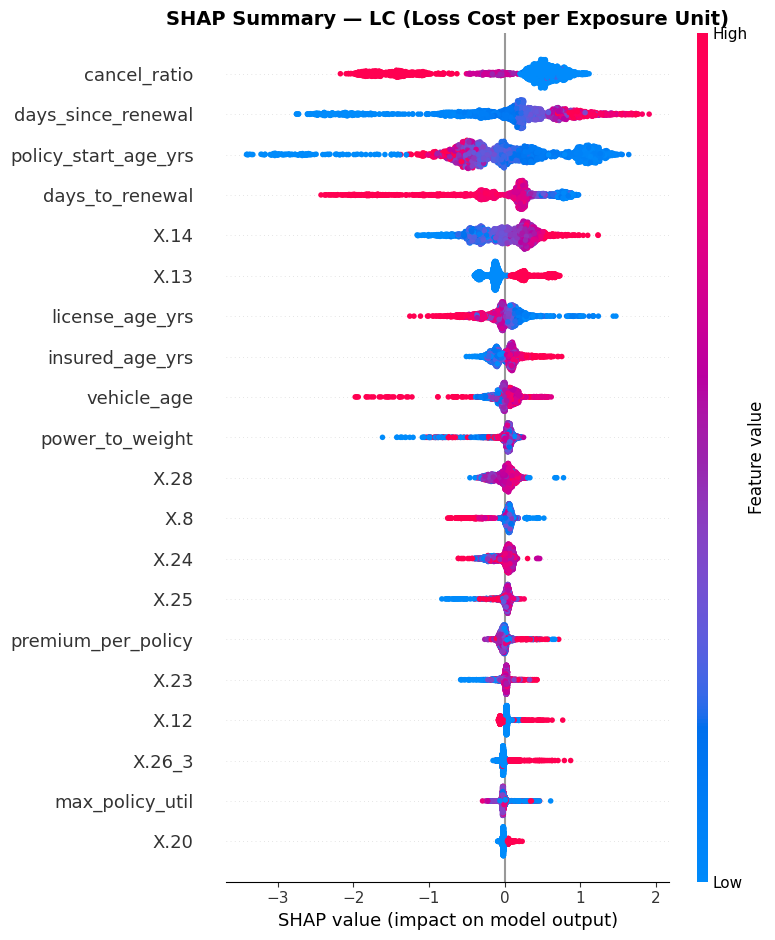

In [7]:
# SHAP beeswarm — LC
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_lc, X_shap, feature_names=feature_names, show=False)
plt.title('SHAP Summary — LC (Loss Cost per Exposure Unit)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_LC_summary.png', dpi=150, bbox_inches='tight')
plt.show()

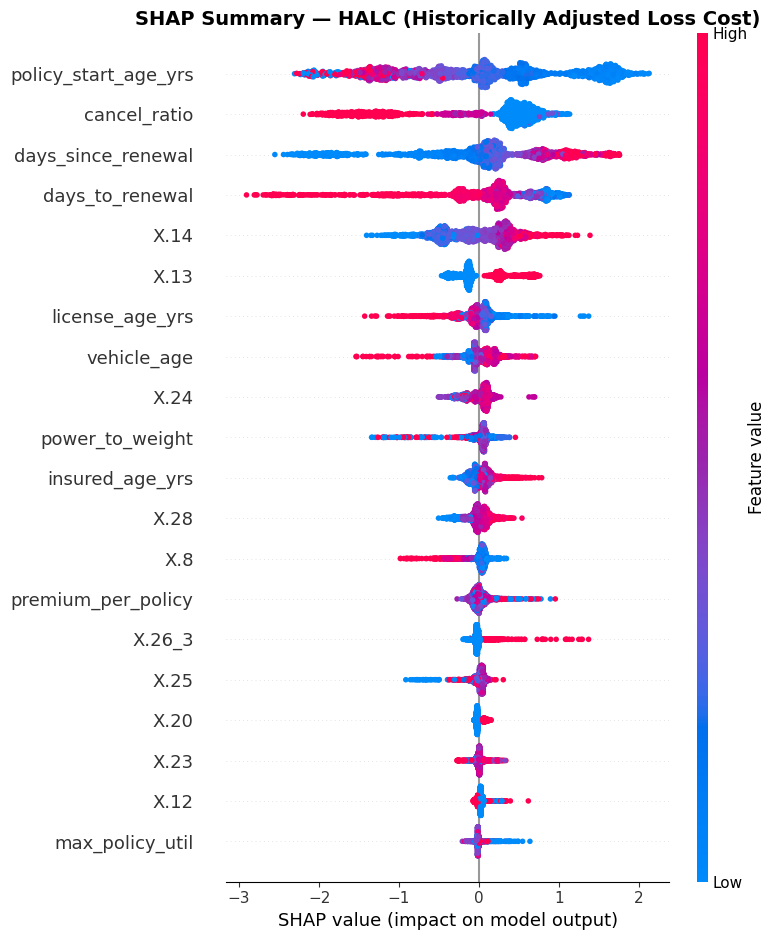

In [8]:
# SHAP beeswarm — HALC
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_halc, X_shap, feature_names=feature_names, show=False)
plt.title('SHAP Summary — HALC (Historically Adjusted Loss Cost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_HALC_summary.png', dpi=150, bbox_inches='tight')
plt.show()

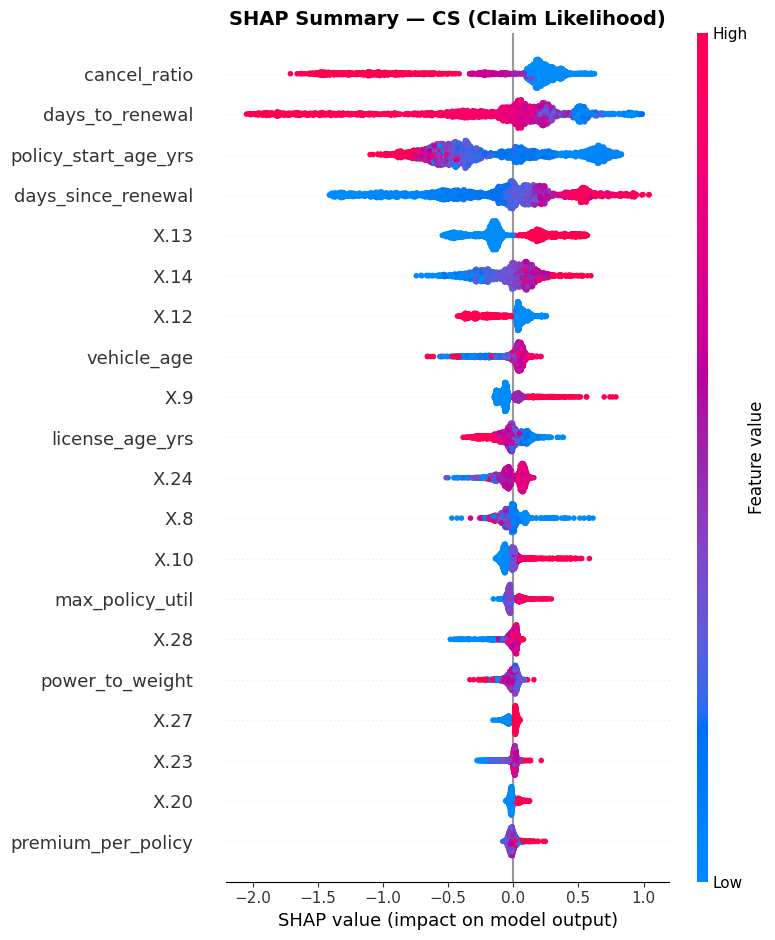

In [9]:
# SHAP beeswarm — CS
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_cs, X_shap, feature_names=feature_names, show=False)
plt.title('SHAP Summary — CS (Claim Likelihood)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_CS_summary.png', dpi=150, bbox_inches='tight')
plt.show()

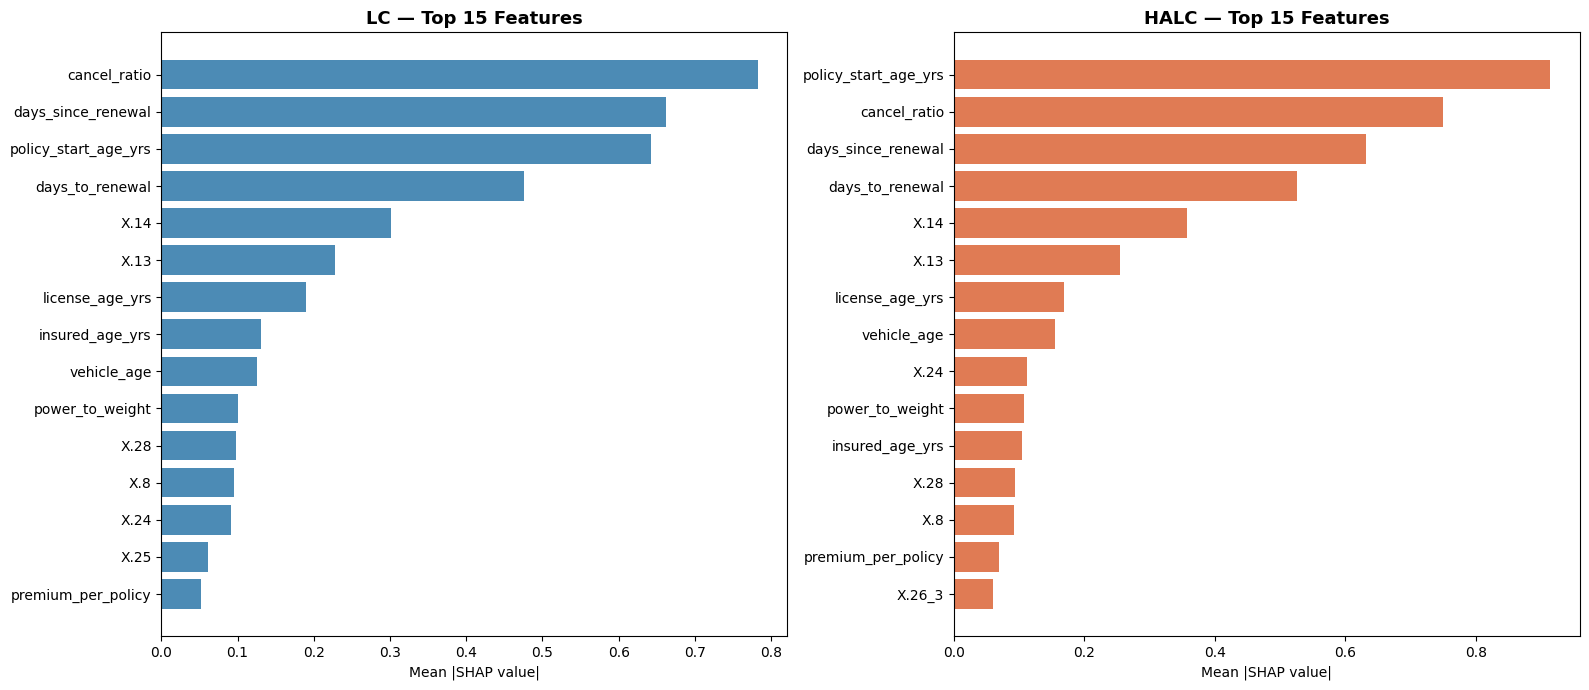


[Unified Insight Across Models]
Behavioral variables such as renewal timing and cancellation history consistently drive:
• Claim likelihood (CS)
• Loss magnitude (LC)
• Adjusted loss cost (HALC)


In [10]:
# Bar chart — LC vs HALC side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, sv, title, color in [
    (axes[0], shap_lc,   'LC — Top 15 Features',  '#4c8bb5'),
    (axes[1], shap_halc, 'HALC — Top 15 Features', '#e07b54')]:
    mean_shap = np.abs(sv).mean(axis=0)
    idx = np.argsort(mean_shap)[-15:]
    ax.barh([feature_names[i] for i in idx], mean_shap[idx], color=color)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_LC_HALC_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Unified Interpretation Across Models ---
print("\n[Unified Insight Across Models]")
print("Behavioral variables such as renewal timing and cancellation history consistently drive:")
print("• Claim likelihood (CS)")
print("• Loss magnitude (LC)")
print("• Adjusted loss cost (HALC)")

In [11]:
# Print top 10 features for each model (use these for business insights)
for sv, name in [(shap_lc, 'LC'), (shap_halc, 'HALC'), (shap_cs, 'CS')]:
    mean_shap = np.abs(sv).mean(axis=0)
    print(f'\n=== TOP 10 FEATURES — {name} ===')
    for i in np.argsort(mean_shap)[::-1][:10]:
        print(f'  {feature_names[i]}: {mean_shap[i]:.4f}')

# --- Risk Segmentation ---
print("\n[Risk Segmentation]")
print("High-risk customers:")
print("• Close to renewal")
print("• Low cancellation ratio (more persistent)")
print("\nLow-risk customers:")
print("• Long-tenure customers")
print("• High cancellation ratio")


=== TOP 10 FEATURES — LC ===
  cancel_ratio: 0.7823
  days_since_renewal: 0.6626
  policy_start_age_yrs: 0.6424
  days_to_renewal: 0.4751
  X.14: 0.3008
  X.13: 0.2272
  license_age_yrs: 0.1895
  insured_age_yrs: 0.1310
  vehicle_age: 0.1252
  power_to_weight: 0.1011

=== TOP 10 FEATURES — HALC ===
  policy_start_age_yrs: 0.9139
  cancel_ratio: 0.7491
  days_since_renewal: 0.6315
  days_to_renewal: 0.5259
  X.14: 0.3578
  X.13: 0.2545
  license_age_yrs: 0.1694
  vehicle_age: 0.1555
  X.24: 0.1119
  power_to_weight: 0.1069

=== TOP 10 FEATURES — CS ===
  cancel_ratio: 0.4659
  days_to_renewal: 0.4652
  policy_start_age_yrs: 0.4537
  days_since_renewal: 0.4082
  X.13: 0.2362
  X.14: 0.1564
  X.12: 0.1297
  vehicle_age: 0.0874
  X.9: 0.0864
  license_age_yrs: 0.0807

[Risk Segmentation]
High-risk customers:
• Close to renewal
• Low cancellation ratio (more persistent)

Low-risk customers:
• Long-tenure customers
• High cancellation ratio


## Step 4: Generate Final Prediction CSV

In [12]:
# Retrain CS on full training data before predicting test set
model_CS.fit(X_full, y_CS, eval_set=[(X_full, y_CS)], verbose=False)

# Predictions
LC_raw   = lgbm_lc.predict(test_X.values).clip(min=0)       # Bobby's LGBM
HALC_raw = lgbm_halc.predict(test_X.values).clip(min=0)     # Bobby's LGBM
CS_pred   = model_CS.predict_proba(test_X.values)[:, 1]      # probabilities for AUC scoring

# set no claim to 0
no_claim = CS_pred < 0.5
LC_pred   = np.where(no_claim, 0.0, LC_raw)
HALC_pred = np.where(no_claim, 0.0, HALC_raw)

submission = pd.DataFrame({'LC': LC_pred, 'HALC': HALC_pred, 'CS': CS_pred})

print('=== FINAL PREDICTION SUMMARY ===')
print(submission.describe().round(3))
print(f'\nShape: {submission.shape}')
print(f'LC == 0:   {(LC_pred == 0).sum()} rows  ({(LC_pred==0).mean()*100:.1f}%)')
print(f'HALC == 0: {(HALC_pred == 0).sum()} rows  ({(HALC_pred==0).mean()*100:.1f}%)')

=== FINAL PREDICTION SUMMARY ===
              LC       HALC         CS
count  13310.000  13310.000  13310.000
mean      38.505     70.261      0.303
std      111.922    210.600      0.275
min        0.000      0.000      0.000
25%        0.000      0.000      0.058
50%        0.000      0.000      0.216
75%       21.936     25.211      0.506
max     2591.450   5306.158      0.986

Shape: (13310, 3)
LC == 0:   9927 rows  (74.6%)
HALC == 0: 9927 rows  (74.6%)


In [13]:
submission.to_csv(OUTPUT_DIR + 'Group_5_prediction.csv', index=False)
print('Saved to Drive!')

Saved to Drive!


In [14]:
# --- Business Application ---
print("\n[Pricing Insight]")
print("Insurers should incorporate behavioral indicators (e.g., renewal timing, cancellation patterns) into pricing strategies.")
print("Ignoring these may lead to adverse selection.")


[Pricing Insight]
Insurers should incorporate behavioral indicators (e.g., renewal timing, cancellation patterns) into pricing strategies.
Ignoring these may lead to adverse selection.
